# Shor's Factoring Algorithm

**Goal:** Factor a composite integer $N$ in polynomial time using quantum period-finding.

## Overview

Shor's algorithm reduces factoring to **order-finding**: given a random $a$ coprime to $N$,
find the smallest $r$ such that $a^r \equiv 1 \pmod{N}$. Once $r$ is known (and even),
$\gcd(a^{r/2} \pm 1, N)$ likely yields a non-trivial factor.

The quantum speedup comes from **Quantum Phase Estimation (QPE)** applied to the
unitary $U|y\rangle = |ay \bmod N\rangle$, which extracts $r$ efficiently.

We'll factor **$N = 15$** using $a = 7$.


In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from math import gcd
from fractions import Fraction
import matplotlib.pyplot as plt


## 1 — Modular Exponentiation Gate

For $N = 15$, $a = 7$, we need controlled-$U^{2^j}$ gates where $U|y\rangle = |7y \bmod 15\rangle$.

The successive powers $7^{2^j} \bmod 15$ are:
- $7^1 \bmod 15 = 7$
- $7^2 \bmod 15 = 4$
- $7^4 \bmod 15 = 1$

Since $7^4 \equiv 1$, the order is $r = 4$. We build custom controlled permutation
gates for each power.


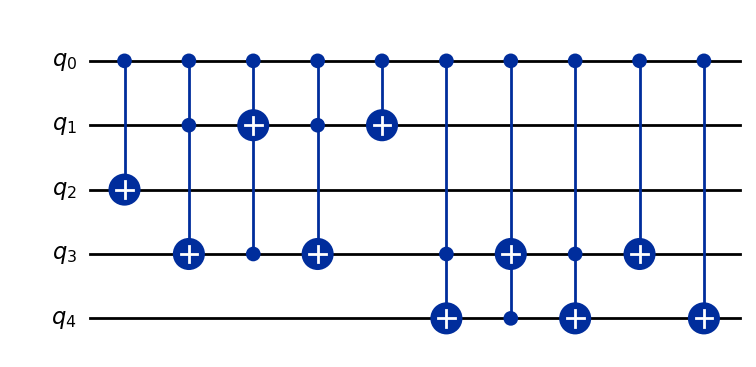

In [7]:
def c_amod15(a, power):
    """Controlled multiplication by a^power mod 15.
    
    For the special case N=15, we hard-code efficient permutation circuits.
    In general Shor's, these would be built from modular arithmetic circuits.
    """
    U = QuantumCircuit(4, name=f"{a}^{power} mod 15")
    
    # Compute a^power mod 15
    a_pow = pow(a, power, 15)
    
    # Permutation circuits for each residue
    if a_pow == 2:
        U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
    elif a_pow == 4:
        U.swap(0, 2); U.swap(1, 3)
    elif a_pow == 7:
        U.swap(0, 2); U.swap(2, 3)
        U.x([0, 1, 2, 3])
    elif a_pow == 8:
        U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
    elif a_pow == 11:
        U.x([0, 1, 2, 3])
        U.swap(2, 3); U.swap(0, 2)
    elif a_pow == 13:
        U.x([0, 1, 2, 3])
        U.swap(0, 2); U.swap(1, 2); U.swap(2, 3)
    elif a_pow == 1:
        pass  # Identity
    
    return U.to_gate().control(1)

# Show the gate for a=7, power=1
example_gate = c_amod15(7, 1)
qc_ex = QuantumCircuit(5)
qc_ex.append(example_gate, range(5))
qc_ex.decompose().draw("mpl", style="iqp")


## 2 — Quantum Phase Estimation Circuit

QPE uses $n_{\text{count}}$ counting qubits to estimate the eigenvalue phase of $U$.
The eigenvalues of $U|y\rangle = |ay\bmod N\rangle$ encode the order $r$ as phases $s/r$.


Circuit: 12 qubits, depth ~11


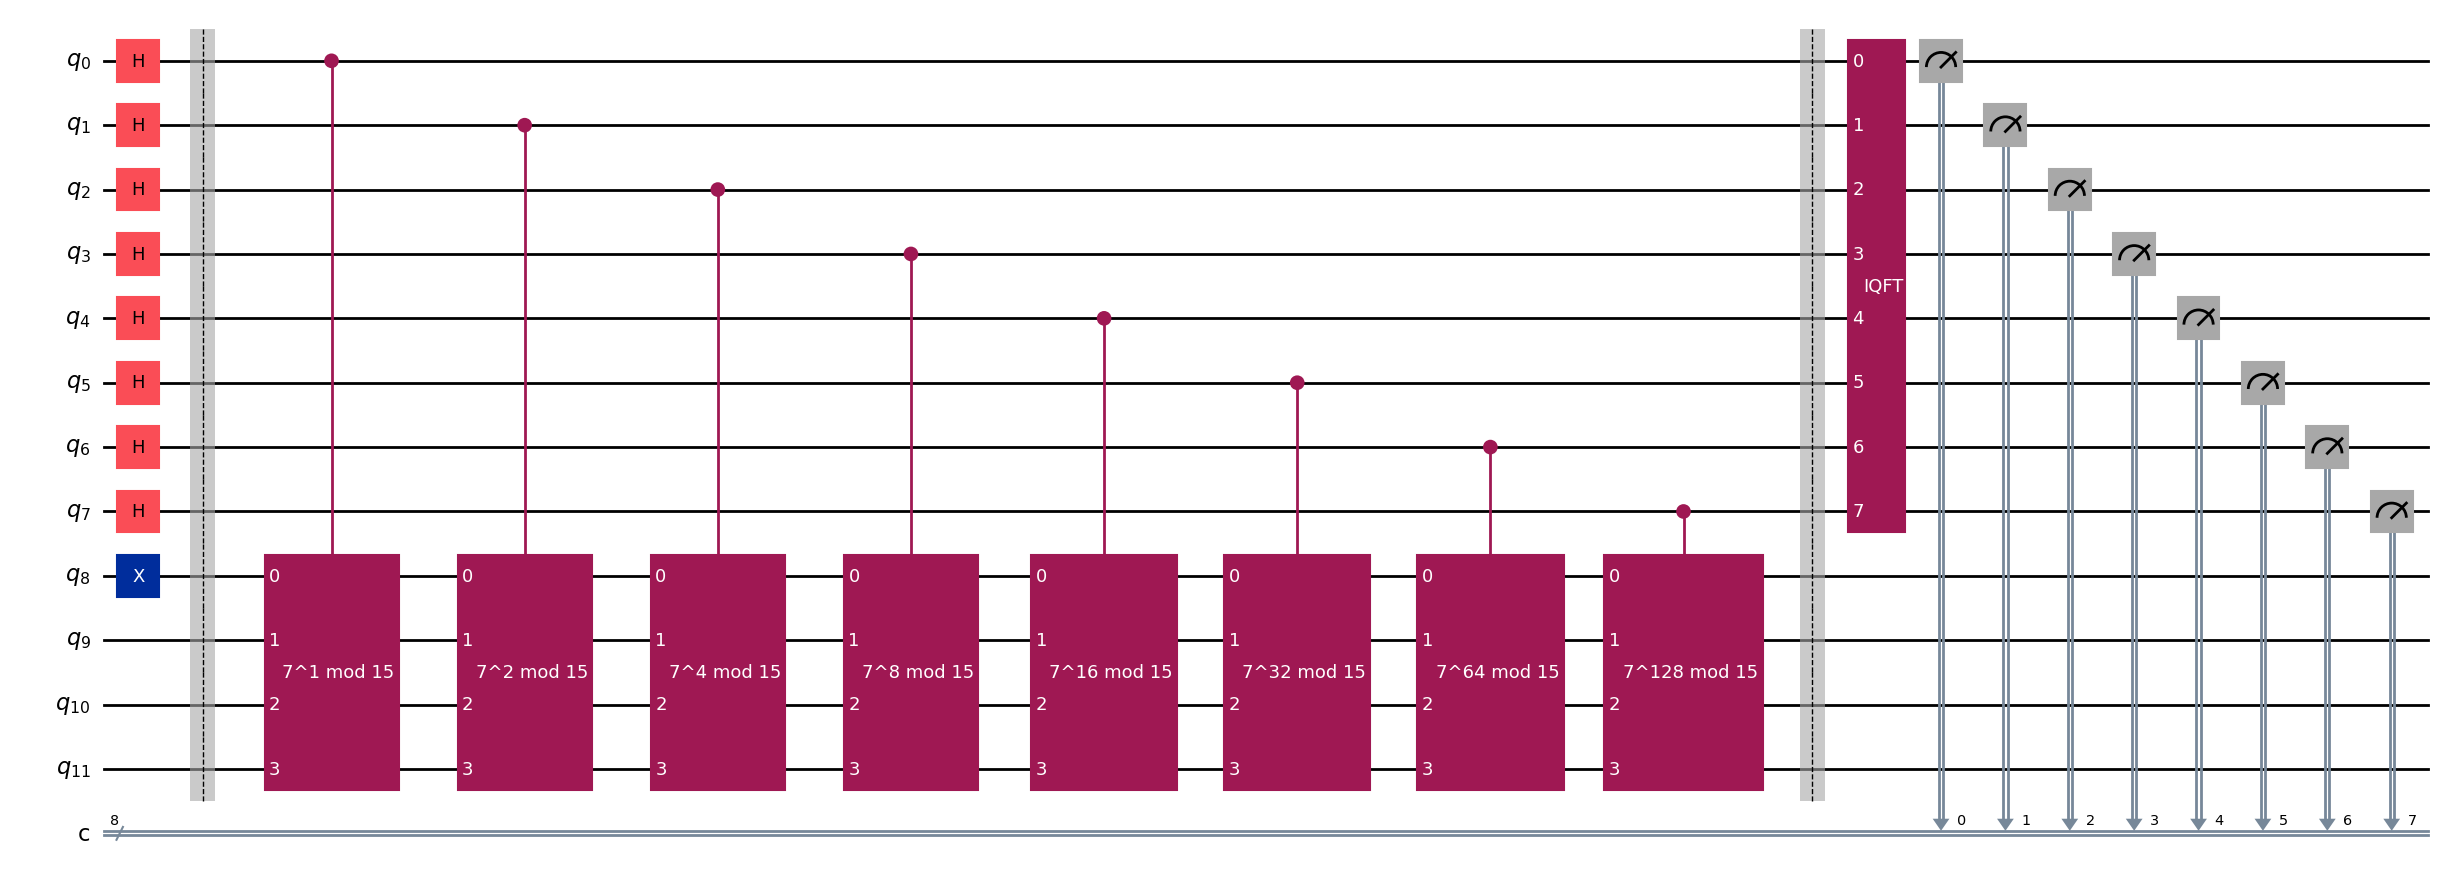

In [8]:
from qiskit.circuit.library import QFTGate

n_count = 8  # counting qubits — precision bits
a = 7
N = 15

qpe = QuantumCircuit(n_count + 4, n_count)

# Initialize work register to |1> (eigenvector support)
qpe.x(n_count)

# Hadamard on counting qubits
qpe.h(range(n_count))
qpe.barrier()

# Controlled-U^(2^j) gates
for j in range(n_count):
    qpe.append(c_amod15(a, 2**j), [j] + list(range(n_count, n_count + 4)))

qpe.barrier()

# Inverse QFT on counting register
iqft = QFTGate(n_count).inverse()
iqft.label = "IQFT"
qpe.append(iqft, range(n_count))

# Measure counting qubits
qpe.measure(range(n_count), range(n_count))

print(f"Circuit: {qpe.num_qubits} qubits, depth ~{qpe.depth()}")
qpe.draw("mpl", style="iqp", fold=40)


## 3 — Simulate and Extract the Period

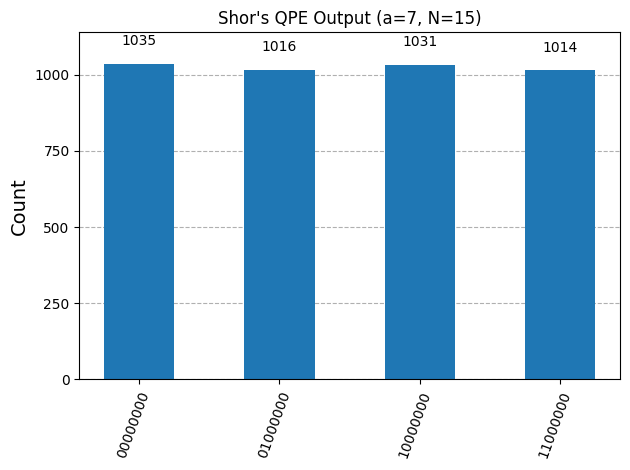

In [9]:
sim = AerSimulator()
compiled = transpile(qpe, sim)
result = sim.run(compiled, shots=4096).result()
counts = result.get_counts()

plot_histogram(counts, title="Shor's QPE Output (a=7, N=15)")



In [11]:
# Classical post-processing: extract r from measured phases
print(f"Factoring N = {N} with a = {a}\n")
print(f"{'Measured':>10}  {'Phase s/r':>12}  {'Period r':>4}  {'Factors':>12}")
print("-" * 50)

measured_phases = sorted(counts.items(), key=lambda x: -x[1])[:4]

for bitstring, freq in measured_phases:
    decimal = int(bitstring, 2)
    phase = decimal / (2 ** n_count)
    
    # Use continued fractions to find s/r
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    
    # Attempt factoring
    if r % 2 == 0:
        guess1 = gcd(a**(r // 2) - 1, N)
        guess2 = gcd(a**(r // 2) + 1, N)
        factors = f"{guess1} × {guess2}" if 1 < guess1 < N else "trivial"
    else:
        factors = "r is odd"
    
    print(f"{bitstring:>10}  {str(frac):>12}  {r:>4}  {factors:>12}")


Factoring N = 15 with a = 7

  Measured     Phase s/r  Period r       Factors
--------------------------------------------------
  00000000             0     1      r is odd
  10000000           1/2     2         3 × 1
  01000000           1/4     4         3 × 5
  11000000           3/4     4         3 × 5


## Analysis

The QPE output concentrates on multiples of $2^8 / r = 256/4 = 64$:
measurements $\{0, 64, 128, 192\}$ correspond to phases $\{0, 1/4, 1/2, 3/4\}$.

Continued fractions extraction yields $r = 4$, and:
$$\gcd(7^{4/2} - 1, 15) = \gcd(48, 15) = 3, \quad \gcd(7^{4/2} + 1, 15) = \gcd(50, 15) = 5$$

So $15 = 3 \times 5$ —> This was successfully factored.

**Key takeaway:** Shor's algorithm achieves an exponential speedup over the best known
classical factoring algorithms, with direct implications for RSA cryptography.
